# 21 cm signal loss under foreground-mode filtering

The paper trail for Fig. 1 (`signal_loss.pdf`) and for the draft prose that
goes with it, end to end: the nominal foreground waterfall and the Zeus21
model ensemble in, the figure plus `signal_loss_text.tex` out.

**The question.** The eigenmode analysis shows that the simulated
beam-weighted foregrounds occupy a low-dimensional spectral subspace. On its
own that says nothing about whether the cosmological signal survives the same
filter. So push an ensemble of global 21 cm models through the *identical*
projection onto the leading $N$ foreground modes, and read the retained signal
off the same axes as the foreground residual.

**Scope, deliberately narrow.** This is the paper's first figure and it makes
the smallest claim that supports the design argument: the beam-weighted
foregrounds are spectrally low-dimensional, and a signal survives projecting
that subspace out. Nothing else is folded in -- no instrumental systematics,
no noise, no knowledge of the beam or the sky. The antenna-position
systematic is *not* drawn here; it belongs to `horizon_shift.ipynb`, which
carries it against this same retained-signal benchmark. It is loaded in §7
only because this notebook also generates that figure's caption.

**Not a proposed analysis.** A blind eigenmode projection is the most
conservative filter available and not what EIGSEP plans to run. These figures
bound spectral subspace overlap, not sensitivity.

**Inputs** (all gitignored -- see `../README.md` to regenerate):

| file | from |
|---|---|
| `foreground_svd.npz` (paper repo) | the nominal zenith waterfall |
| `../../models_21cm/output/zeus21_models.npz` | `models_21cm/generate.py` |
| `horizon_shift.npz` (paper repo) | `horizon_shift.ipynb`, for §7 only |

**Run order.** `horizon_shift.ipynb` first -- §7 and the caption blocks read
the npz it writes.

In [1]:
import inspect
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import nbformat as nbf
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

HERE = Path.cwd()                              # horizon_position/notebooks
sys.path.insert(0, str(HERE.parent))           # paper.py
import paper
sys.path.insert(0, str(paper.ROOT / "models_21cm"))
import selection

PAPER = paper.PAPER
N_SHOW = paper.N_SHOW                          # residual-panel x-axis extent
n_modes = np.arange(N_SHOW + 1)

# Class edges on retained RMS [mK] at N_ANCHOR. 2.0 and 4.5 mK split the Zeus21
# ensemble roughly into thirds; 10 mK would catch ~5% and 25 mK nothing at all.
# Used by the summary table and section 6 only -- the figure draws the ensemble
# as a percentile band, so the bins never reach the reader.
RET_EDGES_MK = (2.0, 4.5)
CLASS_LABELS = ("< 2 mK", "2-4.5 mK", "> 4.5 mK")

# The 21 cm ensemble's grey, identical to horizon_shift.ipynb's C_21. The
# reader meets the band here and reads the same artist again in that figure,
# so the two must not drift. Foregrounds are black; nothing else is drawn.
C_21 = "0.40"

## 1. Inputs

### 1.1 The nominal foreground waterfall

`foreground_svd.npz` holds the zenith-pointing system temperature over one
sidereal day: bowtie beam, GSM16 sky, $T_\mathrm{ground} = 300$ K, realistic
horizon. The receiver temperature is a constant 50 K and is subtracted here.

That subtraction is load-bearing, not cosmetic. The eigenbasis below is built
from the antenna temperature, so the foreground residual has to be measured in
the basis it was built for. Leaving the ~50 K offset in gives the basis a
constant it was never optimised to compress and inflates the apparent residual
by orders of magnitude.

In [2]:
fg = np.load(paper.FG_NPZ)
t_ant = fg["t_sys"] - fg["t_receiver"]         # (n_time, n_f) K
freqs = fg["freqs_MHz"]
n_time, n_f = t_ant.shape

print(f"{n_time} LST samples x {n_f} channels "
      f"({freqs[0]:.0f}-{freqs[-1]:.0f} MHz)")
print(f"T_receiver = {float(fg['t_receiver']):g} K, "
      f"T_ground = {float(fg['t_ground']):g} K, sky = {str(fg['sky_model'])}")
print(f"antenna temperature: {t_ant.min():.1f} - {t_ant.max():.1f} K")

1436 LST samples x 201 channels (50-250 MHz)
T_receiver = 50 K, T_ground = 300 K, sky = gsm16
antenna temperature: 179.4 - 3834.2 K


### 1.2 The 21 cm model ensemble

4096 global-signal models from Zeus21 (Muñoz 2023a, arXiv:2302.08506) with
Pop III star formation and Lyman-Werner feedback (Cruz et al. 2024,
arXiv:2407.18294), Sobol-sampled over 14 astrophysical parameters and already
spline-interpolated onto the paper frequency grid.

The **posterior reionization cut** is applied here, once, so the figure and
the quoted statistics can never disagree about which models are in.
`reionized_across_band` (not plain `reionized`) is deliberate: it also
requires the model to be reionized at the top of the band, excluding 43 models
whose Zeus21 Q-solution re-neutralises at low $z$ -- 27 of those carry more
than 1 mK of unphysical signal at 250 MHz. The $z = 5.9$ threshold is
inherited from McGreer et al. 2015, since superseded by Davies et al. 2025;
it is kept because it is not load-bearing, not because it is conservative --
`../reionization_sensitivity.py` sweeps it, and the reported numbers do not
move.

The survivor-count assert is what stops this figure and `horizon_shift.ipynb`
cutting different ensembles.

In [3]:
m = np.load(paper.MODELS_NPZ, allow_pickle=False)
assert np.array_equal(m["freqs_MHz"], freqs), "21 cm grid != foreground grid"

keep = selection.reionized_across_band(m["xHI"], m["z_xHI"])
T21 = m["T21_mK"][keep] * 1e-3                 # (n_model, n_f) K
assert keep.sum() == paper.N_MODELS, (
    f"{keep.sum()} models survive the cut, expected {paper.N_MODELS} -- "
    "the ensemble moved; update paper.N_MODELS and re-run both notebooks"
)
print(f"{keep.sum()} of {keep.size} models survive the reionization cut")

depth_mK = -T21.min(axis=1) * 1e3
print(f"trough depth: median {np.median(depth_mK):.0f} mK, "
      f"range {depth_mK.min():.0f}-{depth_mK.max():.0f} mK")

1769 of 4096 models survive the reionization cut
trough depth: median 118 mK, range 12-263 mK


## 2. The foreground spectral eigenbasis

The **uncentered** SVD of the antenna-temperature waterfall. Uncentered
matters: the mean spectrum is kept rather than subtracted for free. It is the
dominant foreground and any per-spectrum cleaning has to remove it, so it
counts as mode 1.

`horizon_shift.ipynb` builds the same basis from its own copy of the nominal
waterfall. The assert below is what keeps the two figures projecting onto
identical modes.

In [4]:
U, s_fg, Vh = np.linalg.svd(t_ant, full_matrices=False)

shift = np.load(paper.SHIFT_NPZ, allow_pickle=True)
assert np.array_equal(shift["freqs_MHz"], freqs), "frequency grid mismatch"
assert np.allclose(Vh, shift["Vh"]), (
    "eigenbasis differs from the one horizon_shift.ipynb published -- "
    "re-run that notebook first"
)
print("eigenbasis matches horizon_shift.npz")

print("\nper-channel RMS each mode contributes to one spectrum [K]:")
for i in range(6):
    print(f"  mode {i + 1}: {s_fg[i] / np.sqrt(n_time * n_f):10.4f}")

eigenbasis matches horizon_shift.npz

per-channel RMS each mode contributes to one spectrum [K]:
  mode 1:   727.9799
  mode 2:    23.4086
  mode 3:     2.3571
  mode 4:     1.1899
  mode 5:     0.3855
  mode 6:     0.1160


## 3. The two curves, and the depth the text quotes at

Two curves, both an RMS of what lies outside the leading $N$ modes:

* the **foreground residual** -- what the foregrounds themselves leave behind,
  pooled over every LST and channel. By Parseval this is the singular-value
  tail, $\sqrt{\sum_{i>N} s_i^2 / (n_t n_f)}$.
* the **retained 21 cm signal** -- every surviving model under the identical
  projection, as 5/50/95th percentiles.

Those two are the whole figure. Everything below is for the prose.

$N_\mathrm{ANCHOR}$ is the smallest $N$ at which the foreground residual falls
below the *median* retained signal **and stays below** for every larger $N$.
The stays-below clause is load-bearing: both curves fall with $N$ and cross
more than once, so a first-crossing rule selects an $N$ the floor later climbs
back above.

**Nothing in the figure is drawn at $N_\mathrm{ANCHOR}$.** It is not a marked
line, not a panel depth and not a colour slice; the figure shows two curves
over the whole $N$ axis and lets the crossing speak for itself. The constant
survives because sections 5-7 and the caption blocks have to quote their
millikelvin numbers *somewhere*, and because `horizon_shift.ipynb` needs a
common dimension at which to compare the position systematic against this
ensemble. It is a reporting convention, and both notebooks re-derive and assert
it so they cannot quote at different depths.

That is a deliberate downgrade from the previous version of this figure, which
drew a subsample at $N_\mathrm{ANCHOR}$ in frequency space and keyed a colour
scale to it. A referee had already read the earlier 10 mK residual as a
sensitivity claim; a labelled $N$ in the figure invites exactly the same
misreading, and no caption can undo it. The criterion above is in any case not
a recommendation -- the foreground residual it keys off is an in-sample optimum
for the matrix that defined the basis (see `horizon_shift.ipynb` section 6), so
it is not a floor real data could be held to.

What makes this depth more than arbitrary is established elsewhere:
`horizon_shift.ipynb` shows that around here the term limiting the residual
changes hands, from the foregrounds to whatever the instrument model has wrong.
That is a result of the position analysis, and it is stated there.

In [5]:
def filt_rms(x, Vh, n_modes):
    """RMS over frequency after filtering the leading N modes, per row [K]."""
    c = np.atleast_2d(x) @ Vh.T
    n_f = Vh.shape[0]
    return np.array([np.sqrt(np.sum(c[:, N:] ** 2, axis=1) / n_f)
                     for N in n_modes])                    # (n_modes, n_row)


def filtered(x, Vh, N):
    """The part of x left after projecting out the leading N modes."""
    c = np.atleast_2d(x) @ Vh.T
    return (c[:, N:] @ Vh[N:]).reshape(np.shape(x))


def derive(Vh, s_fg, T21, n_time, n_modes, n_anchor):
    """The four arrays the figure and every quoted number are read off.

    Returns (fg_resid, t21_resid, t21_pct, t21_filt), all in K:
    the foreground residual curve, the per-model retained-RMS curves, their
    5/50/95 percentiles, and each model's residual at the operating point.
    """
    n_f = Vh.shape[0]
    # Parseval: the pooled residual is the singular-value tail.
    tail = np.concatenate([np.cumsum(s_fg[::-1] ** 2)[::-1], [0.0]])
    fg_resid = np.sqrt(tail / (n_time * n_f))[: len(n_modes)]
    t21_resid = filt_rms(T21, Vh, n_modes)                 # (n_modes, n_model)
    t21_pct = np.percentile(t21_resid, [5, 50, 95], axis=1)
    t21_filt = filtered(T21, Vh, n_anchor)                 # (n_model, n_f)
    return fg_resid, t21_resid, t21_pct, t21_filt


def stays_below(curve, ref, n_modes):
    """Smallest N with curve < ref there and at every larger N on the axis."""
    below = curve < ref
    return next((int(N) for N in n_modes if below[N:].all()), None)

In [6]:
fg_resid, t21_resid, t21_pct, t21_filt = derive(
    Vh, s_fg, T21, n_time, n_modes, paper.N_ANCHOR)

N_ANCHOR = stays_below(fg_resid, t21_pct[1], n_modes)
assert N_ANCHOR is not None, "foreground floor never stays below the median"
assert N_ANCHOR == paper.N_ANCHOR, (
    f"derived N_ANCHOR = {N_ANCHOR}, paper.py says {paper.N_ANCHOR}"
)

print(f"{'N':>3}{'fg resid':>11}{'21cm p5':>10}{'21cm p50':>10}{'21cm p95':>11}")
for N in n_modes:
    flag = "  <- N_ANCHOR" if N == N_ANCHOR else ""
    print(f"{N:>3}{fg_resid[N] * 1e3:>10.3f}{t21_pct[0, N] * 1e3:>10.3f}"
          f"{t21_pct[1, N] * 1e3:>10.3f}{t21_pct[2, N] * 1e3:>11.3f}  mK{flag}")
print(f"\nN_ANCHOR = {N_ANCHOR}, matching paper.N_ANCHOR (quoted at, not drawn)")

# Bin each model by what it retains, for the summary table and section 6.
ret_mK = t21_resid[N_ANCHOR] * 1e3
cls = np.digitize(ret_mK, RET_EDGES_MK)

  N   fg resid   21cm p5  21cm p50   21cm p95
  0728361.064    12.211    35.686    102.774  mK
  1 23560.475    10.346    25.062     77.372  mK
  2  2671.195     9.805    19.275     68.763  mK
  3  1256.698     9.449    19.035     65.259  mK
  4   404.133     4.929    13.368     41.495  mK
  5   121.153     3.383     8.795     24.943  mK
  6    34.828     2.893     7.071     21.373  mK
  7    18.445     2.478     6.646     18.879  mK
  8     7.748     1.633     4.944     16.528  mK
  9     1.816     1.046     3.014     10.488  mK  <- N_ANCHOR
 10     0.623     0.773     2.175      7.822  mK
 11     0.317     0.692     1.922      7.097  mK
 12     0.177     0.610     1.771      6.500  mK
 13     0.088     0.485     1.550      5.871  mK
 14     0.051     0.387     1.102      4.647  mK
 15     0.015     0.306     0.954      4.231  mK
 16     0.008     0.241     0.828      3.702  mK
 17     0.005     0.197     0.698      3.531  mK
 18     0.002     0.183     0.606      2.519  mK

N_ANCHOR 

## 4. The figure

One panel, single column: the foreground residual in black, the 21 cm ensemble
as a grey 5-95 band with its median dashed, both against subspace dimension
$N$. Nothing else.

It supersedes the paper's old `foreground_svd_residual.pdf` on that figure's
own axes -- the black curve is the same one, now never shown without the signal
beside it. That is what makes it a *minimal* answer to the referee: the
objection was raised against this exact plot, and the reply lands on it rather
than on a new figure with a new visual language to learn.

**Why a band rather than every curve.** Both were rendered. 1769 individual
curves fill the lower half of the axes with haze that is thickest around
$N \approx 8$-$10$ -- precisely the region a reader has to read carefully.
The band keeps the crossing clean, and it is also what `horizon_shift.ipynb`
already draws for this ensemble, so the reader learns one artist and reuses it.

**Why grey rather than a colour.** The 21 cm band is the same `C_21 = "0.40"`
dashed grey in both figures. Making it the same artist in both matters more
than marking it as this figure's subject, and it keeps the whole figure
greyscale.

**No 10 mK reference line.** The old figure had one and its caption named it.
Once the ensemble is on the plot the meaningful comparison is curve against
curve, and a horizontal threshold competes with that reading while re-centring
the number the referee asked the manuscript to stop leaning on. The comparison
it used to support is now made in the text, where it is stronger: at $N = 8$,
the depth the old prose quoted, the foreground residual is *above* the median
retained signal.

What this figure gives up is the frequency-space view of what survives, which
showed it to be band-edge ringing rather than a residual trough. Retained RMS
is not retained signal *shape*, and with the panel gone the caption has to say
so in words. Section 6 measures it; block 2 states it.

In [7]:
def make_figure(n_modes, t21_pct, fg_resid, c_21, path):
    """Two curves on the old foreground-residual axes: sky, and signal.

    Single column (3.4 in), so this goes in a `figure' environment, not the
    `figure*' the three-panel version needed. Deliberately spare: no depth is
    marked, nothing is coloured, and there is no horizontal reference line --
    the reader is meant to compare the two curves, and every additional artist
    competes with that. See section 4 for why each was dropped.
    """
    fig, ax = plt.subplots(figsize=(3.4, 2.9), layout="constrained")

    # zorder: band under median under foregrounds, so the black curve stays
    # readable where it crosses the ensemble -- the one region that matters.
    ax.fill_between(n_modes, t21_pct[0], t21_pct[2], color=c_21, alpha=0.25,
                    lw=0, zorder=0)
    ax.plot(n_modes, t21_pct[1], color=c_21, lw=1.4, ls="--", zorder=1)
    ax.plot(n_modes, fg_resid, color="k", lw=1.8, zorder=2)

    # Proxy handles: the band and its median are one entry, not two.
    ax.legend(
        handles=[
            Line2D([], [], color="k", lw=1.8, label="beam-weighted foregrounds"),
            Line2D([], [], color=c_21, lw=1.4, ls="--", label="21 cm models"),
        ],
        fontsize=6.5, loc="lower left", framealpha=0.92,
    )

    ax.set_yscale("log")
    ax.set_xlim(0, n_modes[-1])
    ax.set_ylim(1e-5, 3e3)
    ax.grid(True, which="both", ls=":", lw=0.5, alpha=0.5)
    ax.tick_params(labelsize=7)
    # Geometric, not procedural: "filtered" would contradict the vocabulary the
    # captions are held to. The y-label spells out what "outside subspace"
    # means because this is where the reader first meets these axes;
    # horizon_shift.ipynb uses the short form once they are learned.
    ax.set_xlabel("Foreground subspace dimension $N$", fontsize=8)
    ax.set_ylabel("RMS outside the leading $N$ modes [K]", fontsize=8)

    fig.savefig(path, bbox_inches="tight", dpi=600)
    return fig

wrote /home/christian/Documents/research/papers/eigsep_instrument/notebooks/signal_loss.pdf


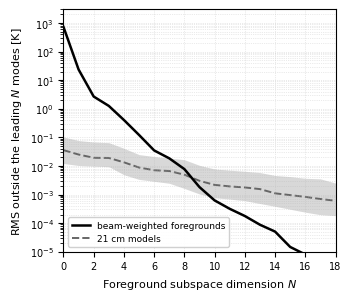

In [8]:
fig_sl = make_figure(n_modes, t21_pct, fg_resid, C_21,
                     PAPER / "signal_loss.pdf")
print(f"wrote {PAPER / 'signal_loss.pdf'}")

## 5. What the projection costs

The headline: at $N_\mathrm{ANCHOR}$ the median model keeps about a tenth of
its RMS, and most of the ensemble still sits above the foreground residual.
This is the section the caption and block 1 take their millikelvin numbers
from -- the figure itself marks no depth, so every number quoted at one is
quoted from here.

The class table underneath answers a different question -- what distinguishes
a model that keeps most of its amplitude from one that does not. At *matched*
trough depth it is width, not amplitude: narrow troughs are the ones that
survive, because a truncated smooth basis cannot represent them.

In [9]:
def print_summary(freqs, T21, t21_resid, t21_pct, fg_resid, cls, class_labels,
                  n_anchor):
    """The numbers this figure contributes to the paper text."""
    frac_above = (t21_resid > fg_resid[:, None]).mean(axis=1)
    print(f"{'N':>3} {'fgnd':>9} {'21cm p50':>9} {'21cm p95':>9} "
          f"{'frac>fgnd':>10}   (mK)")
    for N in (6, 8, n_anchor, 10, 12, 15):
        print(f"{N:3d} {fg_resid[N] * 1e3:9.3f} "
              f"{t21_pct[1, N] * 1e3:9.3f} {t21_pct[2, N] * 1e3:9.3f} "
              f"{frac_above[N]:10.2f}")

    keep = t21_resid[n_anchor] / t21_resid[0]
    print(f"\nAt N = {n_anchor}: median model keeps {np.median(keep) * 100:.0f}% "
          f"of its RMS ({t21_pct[1, n_anchor] * 1e3:.2f} mK), while the "
          f"foreground residual is {fg_resid[n_anchor] * 1e3:.2f} mK.")
    print(f"{frac_above[n_anchor] * 100:.0f}% of the {t21_resid.shape[1]} models "
          f"retain more signal than the foreground residual.")

    # What separates the classes: at matched depth it is width, not amplitude.
    width = (T21 < T21.min(axis=1, keepdims=True) / 2).sum(axis=1) * (
        freqs[1] - freqs[0])
    depth = -T21.min(axis=1) * 1e3
    window = (depth > 80) & (depth < 160)
    print()
    for k, lab in enumerate(class_labels):
        sel, selw = cls == k, (cls == k) & window
        print(f"{lab:>6s} retained: {sel.sum():4d} models, median depth "
              f"{np.median(depth[sel]):6.1f} mK; at matched depth (80-160 mK) "
              f"n={selw.sum():3d}, median trough width "
              f"{np.median(width[selw]):3.0f} MHz")

In [10]:
print_summary(freqs, T21, t21_resid, t21_pct, fg_resid, cls, CLASS_LABELS,
              N_ANCHOR)

  N      fgnd  21cm p50  21cm p95  frac>fgnd   (mK)
  6    34.828     7.071    21.373       0.00
  8     7.748     4.944    16.528       0.30
  9     1.816     3.014    10.488       0.75
 10     0.623     2.175     7.822       0.98
 12     0.177     1.771     6.500       1.00
 15     0.015     0.954     4.231       1.00

At N = 9: median model keeps 10% of its RMS (3.01 mK), while the foreground residual is 1.82 mK.
75% of the 1769 models retain more signal than the foreground residual.

< 2 mK retained:  524 models, median depth   77.0 mK; at matched depth (80-160 mK) n=181, median trough width  36 MHz
2-4.5 mK retained:  657 models, median depth   91.9 mK; at matched depth (80-160 mK) n=310, median trough width  20 MHz
> 4.5 mK retained:  588 models, median depth  155.8 mK; at matched depth (80-160 mK) n=324, median trough width  18 MHz


## 6. Amplitude is not the whole story

Two statistics the text quotes, both about *shape* rather than how much
amplitude survives.

**What predicts survival.** Spearman correlations of the retained RMS against
trough depth, and of the retained *fraction* against trough width. The
fraction, not the absolute RMS, is what isolates shape -- it divides amplitude
out first.

**What stays distinguishable.** Retained RMS says how much amplitude a hard
projection leaves, not what it leaves *measurable*. The pairwise RMS
separation between deep models over 70-130 MHz, before and after filtering, is
the quantity that decides whether the ensemble is still resolvable. It is
computed from the Gram matrix rather than an $(n, n, n_\mathrm{band})$
difference array, which would not fit in memory at this ensemble size.

In [11]:
ret = t21_resid[N_ANCHOR] * 1e3                            # retained RMS [mK]
depth = -T21.min(axis=1) * 1e3
width = (T21 < T21.min(axis=1, keepdims=True) / 2).sum(axis=1) * (freqs[1] - freqs[0])

rho_depth = spearmanr(depth, t21_resid[N_ANCHOR]).statistic
rho_width = spearmanr(width, t21_resid[N_ANCHOR] / t21_resid[0]).statistic
print(f"Spearman(depth, retained RMS)      = {rho_depth:+.2f}")
print(f"Spearman(width, retained fraction) = {rho_width:+.2f}")

near150 = (depth > 140) & (depth < 160)
print(f"\n{near150.sum()} models with a ~150 mK trough retain "
      f"{np.median(ret[near150]):.1f} mK "
      f"({np.percentile(ret[near150], 25):.1f}-"
      f"{np.percentile(ret[near150], 75):.1f} interquartile)")

# Distinguishability over the scoring band, among models with a deep trough.
band = (freqs >= 70) & (freqs <= 130)
deep = depth > 50


def pair_sep(X, deep, band):
    """Upper-triangle pairwise RMS separations over the scoring band [mK]."""
    A = X[deep][:, band] * 1e3
    g = A @ A.T
    dg = np.diag(g)
    d2 = np.maximum(dg[:, None] + dg[None, :] - 2 * g, 0.0)
    iu = np.triu_indices(A.shape[0], k=1)
    return np.sqrt(d2[iu] / band.sum())


sep0, sep1 = pair_sep(T21, deep, band), pair_sep(t21_filt, deep, band)
print(f"\n{deep.sum()} models deeper than 50 mK; median pairwise separation "
      f"over 70-130 MHz falls {np.median(sep0):.0f} -> {np.median(sep1):.1f} mK")
print(f"  still separated by > 1 mK: {(sep1 > 1).mean() * 100:.0f}% of pairs")
print(f"  still separated by > 2 mK: {(sep1 > 2).mean() * 100:.0f}% of pairs")

Spearman(depth, retained RMS)      = +0.53
Spearman(width, retained fraction) = -0.59

247 models with a ~150 mK trough retain 6.3 mK (2.6-8.3 interquartile)

1547 models deeper than 50 mK; median pairwise separation over 70-130 MHz falls 74 -> 6.6 mK
  still separated by > 1 mK: 99% of pairs
  still separated by > 2 mK: 93% of pairs


## 7. The position systematic (for the captions)

Not part of this figure. `horizon_shift.ipynb` owns it, and it is loaded here
only because this notebook generates that figure's caption too -- blocks 4 and
5 of `signal_loss_text.tex`.

Two things get measured. The **cost of folding it in**: the smallest $N$ at
which the worst-axis, worst-LST residual stays below the median retained
signal, minus $N_\mathrm{ANCHOR}$. And the **anatomy of what escapes**: nearly
all of a displacement's power lands in the two leading foreground modes (so it
is more foreground, not a new kind of structure), but what survives the filter
is a spike in a single mode at roughly the signal's amplitude and shape --
which is why a residual excess cannot be read as cosmology.

In [12]:
assert [str(x) for x in shift["labels"]] == ["East", "North", "Up"], (
    "horizon_shift.npz axis order changed; caption blocks 4 and 5 assume E/N/U"
)
mags = shift["mags_m"]
top_mag = float(shift["top_mag_m"])
dT_disp = shift["dT_disp"]                                 # (3 axis, 3 mag, n_lst, n_f)
dT3 = dT_disp[:, int(np.argmin(np.abs(mags - top_mag)))]   # the quoted case

med = t21_pct[1] * 1e3                                     # median retained [mK]


def worst_lst(x, Vh, n_modes):
    """Worst-row residual RMS [mK] vs modes filtered."""
    return filt_rms(x, Vh, n_modes).max(axis=1) * 1e3


per_axis = np.stack([worst_lst(dT3[k], Vh, n_modes) for k in range(3)])
sys_r = worst_lst(dT3.reshape(-1, n_f), Vh, n_modes)       # worst over axis and LST

# The prose no longer counts modes here: the count is a threshold between two
# curves that are equal to within a per cent at N_ANCHOR, and worst-LST puts
# the systematic above the median while the RMS over LST puts it below. Blocks
# 1 and 4 say the two are *equal* there, so that is what gets gated.
sys_pool = np.sqrt(np.mean(filt_rms(dT3[2], Vh, n_modes) ** 2, axis=1)) * 1e3
assert 0.5 < sys_pool[N_ANCHOR] / med[N_ANCHOR] < 2.0, (
    f"the +{top_mag:g} m vertical systematic is no longer comparable to the "
    f"median retained signal at N={N_ANCHOR} ({sys_pool[N_ANCHOR]:.2f} vs "
    f"{med[N_ANCHOR]:.2f} mK) -- blocks 1 and 4 say they are equal there"
)
print(f"at N={N_ANCHOR} the +{top_mag:g} m vertical systematic and the median "
      f"retained signal are equal: {sys_pool[N_ANCHOR]:.2f} mK RMS over LST "
      f"({sys_r[N_ANCHOR]:.2f} worst LST) vs {med[N_ANCHOR]:.2f} mK")

# The basis-mismatch decomposition, carried over from horizon_shift.npz. This
# is what licenses quoting an induced floor instead of a mode count: a
# displaced sky is no harder to compress in its OWN basis, so the excess is the
# price of the wrong horizon and not extra spectral complexity.
pos_names = [str(x) for x in shift["pos_names"]]
floor_own, floor_nom = shift["floor_own"], shift["floor_nom"]
cv_penalty = float(shift["cv_penalty"])
base_floor = floor_own[0] * 1e3


def floors_for(axis, mag):
    """Own- and nominal-basis floor [mK], averaged over displacement sign."""
    ps = [pos_names.index(f"{axis}_{sg}_" + ("%g" % mag).replace(".", "p"))
          for sg in ("m", "p")]
    return floor_own[ps].mean() * 1e3, floor_nom[ps].mean() * 1e3


assert cv_penalty < 1.05, (
    f"held-out LST penalty is now {cv_penalty:.2f}x; block 5 says the basis "
    "generalises across LST at no cost"
)
_own_dev = max(abs(floors_for(a, m)[0] / base_floor - 1)
               for a in "xyz" for m in (float(mags.min()), top_mag))
assert _own_dev < 0.05, (
    f"a displaced sky's own-basis floor now moves by {_own_dev * 100:.0f}% at "
    f"<= {top_mag:g} m; block 5 says it does not move"
)
print(f"\nnominal floor {base_floor:.2f} mK; held-out LST penalty "
      f"{cv_penalty:.2f}x")
for ax, lab in (("x", "East"), ("y", "North"), ("z", "Up")):
    for mg in mags:
        o, nmb = floors_for(ax, mg)
        print(f"  {lab:5s} {mg:5g} m   own {o:6.2f} mK   nominal {nmb:7.2f} mK"
              f"   floor x{nmb / base_floor:5.2f}")

# --- anatomy of what the displacement leaves behind -------------------------
up = dT3[2]                                                # binding axis at every N
cu = up @ Vh.T
j = int(np.argmax(np.sqrt(np.sum(cu[:, N_ANCHOR:] ** 2, axis=1))))   # worst LST
mode_mK = np.abs(cu[j]) / np.sqrt(n_f) * 1e3               # per-mode RMS
lead_frac = np.sum(cu[j, :2] ** 2) / np.sum(cu[j] ** 2)
spike = int(np.argmax(mode_mK[N_ANCHOR:])) + N_ANCHOR      # 0-indexed
tail_pow = np.sum(mode_mK[N_ANCHOR:] ** 2)

c21 = T21 @ Vh.T
fg_mode_mK = s_fg / np.sqrt(n_time * n_f) * 1e3
sig_mode_mK = np.abs(c21[:, spike]) / np.sqrt(n_f) * 1e3

# shape confusion between the leftover systematic and the retained signal
resid_sys = cu[j, N_ANCHOR:] @ Vh[N_ANCHOR:]
r21 = c21[:, N_ANCHOR:] @ Vh[N_ANCHOR:]
cos = np.abs(r21 @ resid_sys) / (
    np.linalg.norm(r21, axis=1) * np.linalg.norm(resid_sys))

print(f"\nUp +{top_mag:g} m at its worst LST: {lead_frac * 100:.1f}% of its power "
      f"is in the two leading modes, but after filtering {N_ANCHOR} the "
      f"remainder is {mode_mK[spike] ** 2 / tail_pow * 100:.0f}% mode "
      f"{spike + 1} alone, at {mode_mK[spike]:.2f} mK "
      f"(that mode holds {fg_mode_mK[spike]:.2f} mK of nominal foreground and "
      f"{np.median(sig_mode_mK):.2f} mK of median 21 cm signal)")
print(f"cosine similarity with the retained signal: median {np.median(cos):.2f}, "
      f"max {cos.max():.2f}")

# Scaling the 1 m case is legitimate only for the vertical axis: a vertical
# shift lowers the horizon by a near-uniform offset, whereas a horizontal one
# moves it by an amount set by where the cliff edges fall in azimuth. Measured
# here rather than asserted, so the prose cannot outlive the fact.
spec_m = 0.1 * med[N_ANCHOR] / mode_mK[spike] * top_mag
up_curves = [worst_lst(dT_disp[2, k], Vh, n_modes) for k in range(mags.size)]
up_r = np.array([cur[N_ANCHOR] for cur in up_curves])
up_dev = np.abs((up_r[1:] / up_r[:-1]) / (mags[1:] / mags[:-1]) - 1) * 100
up_clear = [stays_below(cur, med, n_modes) for cur in up_curves]
print(f"\nUp is linear to {up_dev.max():.0f}% per decade; holding its injection "
      f"to a tenth of the median retained signal needs {spec_m:.1f} m")

at N=9 the +1 m vertical systematic and the median retained signal are equal: 3.01 mK RMS over LST (3.20 worst LST) vs 3.01 mK

nominal floor 1.82 mK; held-out LST penalty 1.00x
  East    0.1 m   own   1.82 mK   nominal    1.82 mK   floor x 1.00
  East      1 m   own   1.81 mK   nominal    2.04 mK   floor x 1.13
  East     10 m   own   1.83 mK   nominal   11.20 mK   floor x 6.17
  North   0.1 m   own   1.81 mK   nominal    1.81 mK   floor x 1.00
  North     1 m   own   1.81 mK   nominal    1.81 mK   floor x 1.00
  North    10 m   own   1.82 mK   nominal    2.40 mK   floor x 1.32
  Up      0.1 m   own   1.82 mK   nominal    1.84 mK   floor x 1.01
  Up        1 m   own   1.82 mK   nominal    3.52 mK   floor x 1.94
  Up       10 m   own   1.84 mK   nominal   30.29 mK   floor x16.68

Up +1 m at its worst LST: 99.9% of its power is in the two leading modes, but after filtering 9 the remainder is 99% mode 10 alone, at 3.18 mK (that mode holds 1.71 mK of nominal foreground and 1.66 mK of medi

## 8. Export to the paper repository

The paper repo's convention is a committed npz (archived to Zenodo) plus a
*standalone* notebook that regenerates the PDF from it -- it cannot import
anything from this repo and has no access to the Zeus21 ensemble.

The plotting code is not duplicated: `inspect.getsource` lifts the functions
defined above out of the running kernel, so the exported notebook contains
byte-identical code to what produced the figure here.

In [13]:
PAPER_MD = r"""
# 21 cm signal loss under foreground-mode projection

The eigenmode analysis shows that the simulated beam-weighted foregrounds occupy a low-dimensional spectral subspace. On its own that says nothing about whether the cosmological signal survives the same projection, so here we push an ensemble of global 21 cm models through the *identical* projection onto the leading $N$ foreground modes and read the retained signal off the same axes as the foreground residual.

One panel, single column: the foreground residual in black, and the 21 cm ensemble as a grey 5-95 per cent band with its median dashed. It supersedes `foreground_svd_residual.pdf` on that figure's own axes -- the black curve is the same one, now never shown without the signal beside it. That is the point of keeping it minimal: the referee's objection was raised against that exact plot, and this answers it there rather than in a new figure with a new visual language.

**Nothing is drawn at a particular $N$.** An earlier version of this figure showed the ensemble in frequency space before and after projecting out $N = 9$ modes, with each curve coloured by the RMS it retained there. Both the panel and the colour scale needed *a* depth, which put a labelled $N = 9$ in the figure. That invites reading the number as an operating point the experiment adopts, which is the same misreading the 10 mK residual already attracted, and no caption undoes it. The figure now shows two curves over the whole $N$ axis and lets the crossing speak for itself. $N = 9$ survives only as the depth the *text* quotes millikelvin numbers at, and as the common dimension at which `horizon_shift.pdf` compares the position systematic against this same ensemble.

**No 10 mK reference line**, for the same reason: once the ensemble is on the plot the meaningful comparison is curve against curve, and a horizontal threshold re-centres the number the manuscript is trying to stop leaning on. The comparison it supported is stronger stated in the text -- at $N = 8$, the depth the previous prose quoted, the foreground residual (7.75 mK) is still *above* the median retained signal (4.94 mK), and only 30 per cent of the ensemble retains more than the foregrounds leave. At $N = 9$ the residual falls to 1.82 mK against a median retained 3.01 mK, and 75 per cent of models retain more.

**Why a band rather than every model.** Both renderings were compared. 1769 individual curves fill the lower half of the axes with haze that is densest around $N \approx 8$-$10$, which is the region the reader has to read most carefully; the band keeps the crossing clean. Grey dashed is also exactly what `horizon_shift.pdf` draws for this ensemble, so the reader learns one artist and reads it twice.

**Scope.** This figure makes the smallest claim that supports the design argument: the beam-weighted foregrounds are spectrally low-dimensional, and a signal survives projecting that subspace out. Nothing else is folded in -- no instrumental systematics, no noise, and no knowledge of the beam or the sky. Instrumental terms enter at `horizon_shift.pdf`, which carries the antenna-position systematic against this same retained-signal benchmark. Read this as a statement about spectral shape overlap, not as the analysis EIGSEP will run -- the planned analysis is a joint differentiable forward-model fit in which beam chromaticity is modelled rather than removed.

**Retained RMS is not retained signal shape.** With the frequency-space panel gone this has to be said rather than seen: what lies outside the subspace is largely band-edge ringing from projecting onto a truncated smooth basis, not a residual absorption trough. The share of surviving power inside 70-130 MHz is 40 per cent at $N = 9$ against 30 per cent for a residual with no preference at all, and it falls to 21 per cent by $N = 18$. What survives is better judged by whether models stay *distinguishable*: among the 1547 models with troughs deeper than 50 mK, the median pairwise separation over 70-130 MHz falls from 74 to 6.6 mK under the projection, yet 99 per cent of pairs remain separated by more than 1 mK and 93 per cent by more than 2 mK.

**Retention is a continuum and no single summary statistic predicts it.** It is set by how much of a model's spectral shape lies in the leading foreground modes. Separating shape from amplitude over the ensemble (Spearman): trough width correlates with the retained *fraction* at -0.59 -- narrower troughs keep proportionally more -- while the *absolute* retained RMS correlates with amplitude only moderately (depth, +0.53). Neither predicts retention alone: the three classes' median depths rise with retained RMS (77, 92, 156 mK for < 2 mK, 2-4.5 mK and > 4.5 mK) but even at matched depth (80-160 mK) they still separate by width -- median trough widths of 36, 20 and 18 MHz respectively. The summary cell bins the distribution at 2 and 4.5 mK for the caption; those bins are a reporting convenience, not populations, and the figure does not draw them.

**Limitations, to be stated wherever this result is used.** The modes come from a single simulated sky (GSM16) and beam, with no noise and no receiver systematics; in practice the basis would be estimated from data that already contain the signal, which costs additional signal loss not captured here. The projection is a hard cut, whereas a joint signal-plus-foreground fit would recover some of what is removed. Signal loss is severe in absolute terms, and whether the retained amplitude is detectable is set by thermal noise and integration time, which this calculation does not model. This is a statement about spectral subspace overlap, not a sensitivity forecast.

Ensemble: 1769 of 4096 Zeus21 models (Munoz 2023a, arXiv:2302.08506, with Pop III and Lyman-Werner feedback, Cruz+2024, arXiv:2407.18294) survive a posterior reionization cut requiring xHI below threshold both at the dark-pixel reference redshift (z = 5.9) and at the top of the observed band (z = 4.6816, 250 MHz). The z = 5.9 threshold of 0.1 was chosen against McGreer+2015, since superseded by Davies+2025 (arXiv:2510.25829); it is kept because it is not load-bearing: sweeping the threshold from 0.06 to 0.25, or dropping the z ~ 6 anchor entirely, leaves N = 9 where it is and holds the above-floor fraction within 0.8 points across the range the current data allow (3.7 points with no anchor at all). See `horizon_position/reionization_sensitivity.py`. The npz carries its own regeneration recipe (`provenance`, `generator_source`, `env_lock` keys); see `docs/superpowers/specs/2026-08-19-zeus21-model-ensemble-design.md`.

The ensemble runs to $z = 4.65$ (251.4 MHz), below Zeus21's advertised $z = 5$-35 validity range. This is deliberate, so the 250 MHz band edge is covered by computed values rather than extrapolation; zero-padding above Zeus21's native top of range ($z = 5$, 236.7 MHz) was considered and rejected instead, because late-reionization models still carry up to ~14 mK of signal at 237 MHz and the resulting step discontinuity would survive a smooth-mode projection and inflate the retained-RMS statistic reported here.
"""


IMPORTS_SRC = """import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D"""

LOAD_SRC = f"""d = np.load("signal_loss.npz", allow_pickle=True)
freqs = d["freqs_MHz"]           # (n_f,) MHz
Vh = d["Vh"]                     # (n_f, n_f) foreground spectral modes
s_fg = d["s_fg"]                 # (n_f,) singular values of the T_ant waterfall
n_time = int(d["n_time"])        # LST samples in that waterfall
T21 = d["T21_models"]            # (n_model, n_f) global-signal ensemble [K]
cls = d["cls"]                   # (n_model,) retained-RMS bin, for the summary
class_labels = [str(x) for x in d["class_labels"]]
N_ANCHOR = int(d["n_anchor"])    # the depth the paper text quotes at; the
                                 # figure marks no depth and does not use it
n_modes = np.arange({N_SHOW} + 1)
C_21 = "0.40"                    # 21 cm grey, shared with horizon_shift.pdf
print(f"{{T21.shape[0]}} 21 cm models on {{freqs.size}} channels, "
      f"{{freqs[0]:.0f}}-{{freqs[-1]:.0f}} MHz")"""

CALLS_SRC = """fg_resid, t21_resid, t21_pct, t21_filt = derive(
    Vh, s_fg, T21, n_time, n_modes, N_ANCHOR)
fig = make_figure(n_modes, t21_pct, fg_resid, C_21, "signal_loss.pdf")
print_summary(freqs, T21, t21_resid, t21_pct, fg_resid, cls, class_labels,
              N_ANCHOR)"""


def export(path, markdown, load_src, funcs, calls):
    """Write a standalone paper-repo notebook: prose, imports, load, code, calls."""
    src = "\n\n\n".join(inspect.getsource(f).rstrip() for f in funcs)
    nb = nbf.v4.new_notebook()
    nb.cells = [
        nbf.v4.new_markdown_cell(markdown.strip()),
        nbf.v4.new_code_cell(IMPORTS_SRC.strip()),
        nbf.v4.new_code_cell(load_src.strip()),
        nbf.v4.new_code_cell(src),
        nbf.v4.new_code_cell(calls.strip()),
    ]
    nbf.write(nb, path)
    print(f"wrote {path}")

In [14]:
np.savez_compressed(
    paper.SIGNAL_LOSS_NPZ,
    freqs_MHz=freqs,
    Vh=Vh,
    s_fg=s_fg,
    n_time=n_time,
    T21_models=T21,
    cls=cls,
    class_labels=np.array(CLASS_LABELS),
    n_anchor=N_ANCHOR,
    description=(
        "Inputs for the 21 cm signal-loss figure. Vh (n_freq, n_freq) and "
        "s_fg (n_freq,) are the right singular vectors and singular values "
        "of the nominal antenna-temperature waterfall (foreground_svd.npz "
        "t_sys minus the constant receiver temperature, n_time LST samples) "
        "-- the same modes as Fig. 1. T21_models "
        "(n_model, n_freq) [K] is the full surviving 21 cm model ensemble "
        "(reionization cut applied) interpolated onto freqs_MHz; the figure "
        "draws it as 5/50/95th percentiles, and every quoted statistic uses "
        "the full array. cls bins each model by the RMS it retains at "
        "n_anchor, for the summary table only. n_anchor is the dimension the "
        "paper text quotes millikelvin numbers at and at which "
        "horizon_shift.npz compares the position systematic against this "
        "ensemble; the figure marks no dimension. Signal and foregrounds are "
        "projected onto the same leading modes of Vh. The +1 m "
        "antenna-position systematic is deliberately not here: it belongs "
        "to horizon_shift.npz, which carries it against the same retained-"
        "signal benchmark. Produced by "
        "mock_analysis/horizon_position/notebooks/signal_loss.ipynb."
    ),
)
print(f"wrote {paper.SIGNAL_LOSS_NPZ}  ({T21.shape[0]} models)")

export(
    PAPER / "signal_loss.ipynb",
    markdown=PAPER_MD,
    load_src=LOAD_SRC,
    funcs=(filt_rms, filtered, derive, make_figure, print_summary),
    calls=CALLS_SRC,
)

wrote /home/christian/Documents/research/papers/eigsep_instrument/notebooks/signal_loss.npz  (1769 models)
wrote /home/christian/Documents/research/papers/eigsep_instrument/notebooks/signal_loss.ipynb


## 9. The draft paper text

`signal_loss_text.tex` is a staging file to paste from -- nothing in this repo
writes to the paper's own `.tex` sources. Every number in it is substituted
from the arrays above, so the prose and the figures cannot drift apart.

The template lives in `../signal_loss_text.tex.in` with `@@TOKEN@@`
placeholders. A previous version of this text was written once and then went
stale: it still quoted a 1135-model ensemble and an $N = 10$ operating point
months after both had changed. Generating it is what stops that recurring.

In [15]:
# Where the limiting term changes hands, and what removing every mode on the
# plot would actually buy. horizon_shift.ipynb derives the same crossing from
# the same arrays and asserts it equals N_ANCHOR; this recomputes it for the
# prose so the two cannot disagree.
fgm = fg_resid * 1e3
hand = next(N for N in n_modes if sys_pool[N] >= fgm[N])
hand_stay = next(N for N in n_modes if (sys_pool[N:] > fgm[N:]).all())
assert hand == N_ANCHOR, (
    f"the limit changes hands at N={hand}, not N_ANCHOR={N_ANCHOR}; blocks 1 "
    "and 5 say they coincide"
)
NEND = int(n_modes[-1])
trough = (freqs >= 70) & (freqs <= 130)


def trough_frac(N):
    """Fraction of the surviving 21 cm power inside the trough band."""
    kept = t21_coef[:, N:] @ Vh[N:]
    return np.median((kept[:, trough] ** 2).sum(axis=1) / (kept ** 2).sum(axis=1))


t21_coef = T21 @ Vh.T

def _sci(x):
    """LaTeX mantissa-exponent form, for the leakage fractions."""
    e = int(np.floor(np.log10(x)))
    return rf"{x / 10 ** e:.1f}\times10^{{{e}}}"


def _leak_dec(power):
    """Fraction of power outside the two leading modes, and decades 1 -> 10."""
    return _sci(1 - power[:2].sum() / power.sum()), f"{np.log10(power[0] / power[9]):.0f}"


fg_pow = s_fg ** 2
LEAKFG, DECFG = _leak_dec(fg_pow)
axis_pow = [(dT3[k] @ Vh.T) ** 2 for k in range(3)]
axis_pow = [p.sum(axis=0) for p in axis_pow]
(LEAKE, _), (LEAKN, _), (LEAKU, DECU) = [_leak_dec(p) for p in axis_pow]

t_ant_rms = np.sqrt(fg_pow.sum() / (n_time * n_f))            # K
dT_up_rms = np.sqrt(axis_pow[2].sum() / (dT3.shape[1] * n_f))  # K
up_pool_na = np.sqrt(axis_pow[2][N_ANCHOR:].sum() / (dT3.shape[1] * n_f))

own_small = [floors_for(a, m)[0] for a in "xyz" for m in (float(mags.min()), top_mag)]
own_big = [floor_own[i] * 1e3 for i, nm in enumerate(pos_names)
           if nm.endswith("_" + ("%g" % mags.max()).replace(".", "p"))]

lo, mid, hi = (int(np.argmin(mags)),
               int(np.argmin(np.abs(mags - top_mag))),
               int(np.argmax(mags)))

vals = {
    # Figure width in inches, read off make_figure so the environment note in
    # the template cannot outlive a resize. FIGWOLD is the three-panel version
    # this replaced, quoted only to explain why `figure*' is no longer needed.
    "FIGW": f"{fig_sl.get_size_inches()[0]:g}",
    "FIGWOLD": "7.6",
    "NMODELS": T21.shape[0],
    "NA": N_ANCHOR,
    "NAM1": N_ANCHOR - 1,
    "FG": f"{fg_resid[N_ANCHOR] * 1e3:.2f}",
    "FGM1": f"{fg_resid[N_ANCHOR - 1] * 1e3:.2f}",
    "MEDM1": f"{med[N_ANCHOR - 1]:.2f}",
    "MED": f"{med[N_ANCHOR]:.2f}",
    "MEDNP1": f"{med[N_ANCHOR + 1]:.2f}",
    "KEEPPCT": f"{np.median(t21_resid[N_ANCHOR] / t21_resid[0]) * 100:.0f}",
    "ABOVE": f"{(ret > fg_resid[N_ANCHOR] * 1e3).mean() * 100:.0f}",
    "N150": int(near150.sum()),
    "RET150": f"{np.median(ret[near150]):.1f}",
    "RET150LO": f"{np.percentile(ret[near150], 25):.1f}",
    "RET150HI": f"{np.percentile(ret[near150], 75):.1f}",
    "RHODEPTH": f"{rho_depth:+.2f}",
    "RHOWIDTH": f"{rho_width:+.2f}",
    "SYSNA": f"{sys_r[N_ANCHOR]:.2f}",
    "SYSNP1": f"{sys_r[N_ANCHOR + 1]:.2f}",
    "NDEEP": int(deep.sum()),
    "SEP0": f"{np.median(sep0):.0f}",
    "SEP1": f"{np.median(sep1):.1f}",
    "PAIR1": f"{(sep1 > 1).mean() * 100:.0f}",
    "PAIR2": f"{(sep1 > 2).mean() * 100:.0f}",
    "NLST": dT3.shape[1],
    "CLEAR_E": stays_below(per_axis[0], med, n_modes),
    "CLEAR_N": stays_below(per_axis[1], med, n_modes),
    "CLEAR_U": stays_below(per_axis[2], med, n_modes),
    # RMS over every LST and channel, NOT the worst-LST value the residual
    # panels track. This is the statistic the surrounding body text already
    # quotes for these three displacements, and a caption that switched to
    # worst-LST would read as contradicting it.
    "RAW_E": f"{np.sqrt(np.mean(dT3[0] ** 2)) * 1e3:.0f}",
    "RAW_N": f"{np.sqrt(np.mean(dT3[1] ** 2)) * 1e3:.0f}",
    "RAW_U": f"{np.sqrt(np.mean(dT3[2] ** 2)) * 1e3:.0f}",
    "MAXDT": f"{np.abs(dT3[2]).max():.1f}",
    "LEADPCT": f"{lead_frac * 100:.1f}",
    "SPIKE": spike + 1,  # 1-indexed for the prose
    "SPIKEPCT": f"{mode_mK[spike] ** 2 / tail_pow * 100:.0f}",
    "SPIKESYS": f"{mode_mK[spike]:.2f}",
    "SPIKEFG": f"{fg_mode_mK[spike]:.2f}",
    "SPIKE21": f"{np.median(sig_mode_mK):.2f}",
    "SPIKEBELOW": f"{(sig_mode_mK < mode_mK[spike]).mean() * 100:.0f}",
    "COSMED": f"{np.median(cos):.2f}",
    "COSMAX": f"{cos.max():.2f}",
    "SPECM": f"{spec_m:.1f}",
    "UPDEV": f"{up_dev.max():.0f}",
    "MAGLO": f"{mags.min():g}",
    "MAGHI": f"{mags.max():g}",
    "TOPMAG": f"{top_mag:g}",
    # --- a position error is not "more foreground" ---------------------------
    "MAXDT_E": f"{np.abs(dT3[0]).max():.1f}",
    "MAXDT_N": f"{np.abs(dT3[1]).max():.1f}",
    "SYSE": f"{per_axis[0][N_ANCHOR]:.2f}",
    "SYSN": f"{per_axis[1][N_ANCHOR]:.2f}",
    "SYSU": f"{per_axis[2][N_ANCHOR]:.2f}",
    "SYSUPOOL": f"{sys_pool[N_ANCHOR]:.2f}",
    "LEAKFG": LEAKFG, "LEAKE": LEAKE, "LEAKN": LEAKN, "LEAKU": LEAKU,
    "DECFG": DECFG, "DECU": DECU,
    "TANT": f"{t_ant_rms:.0f}",
    "COMPFG": _sci(t_ant_rms / fg_resid[N_ANCHOR]),
    "DTU": f"{dT_up_rms:.1f}",
    "COMPU": f"{dT_up_rms / up_pool_na:.0f}",
    # --- the floor is a property of a horizon that is known ------------------
    "NTIME": n_time, "NFREQ": n_f, "NRANK": min(n_time, n_f),
    "CVPEN": f"{cv_penalty:.2f}",
    "OWNLO": f"{min(own_small):.2f}", "OWNHI": f"{max(own_small):.2f}",
    "OWNLO10": f"{min(own_big):.2f}", "OWNHI10": f"{max(own_big):.2f}",
    "FLOORE1": f"{floors_for('x', top_mag)[1]:.2f}",
    "FLOORN1": f"{floors_for('y', top_mag)[1]:.2f}",
    "FLOORU1": f"{floors_for('z', top_mag)[1]:.2f}",
    "FLOORU01": f"{floors_for('z', float(mags.min()))[1]:.2f}",
    "FLOORU10": f"{floors_for('z', float(mags.max()))[1]:.0f}",
    "FLOORU01PCT": f"{(floors_for('z', float(mags.min()))[1] / base_floor - 1) * 100:.0f}",
    # --- the handover, and why deeper is not better -------------------------
    "HANDPREV": hand - 1,
    "HANDFAC": f"{fgm[hand - 1] / sys_pool[hand - 1]:.1f}",
    "HANDSTAY": hand_stay,
    "NEND": NEND,
    "HANDEND": f"{sys_pool[NEND] / fgm[NEND]:.1f}",
    "SIGSYSNA": f"{med[N_ANCHOR] / sys_pool[N_ANCHOR]:.1f}",
    "SIGSYSEND": f"{med[NEND] / sys_pool[NEND]:.0f}",
    "KEEPEND": f"{np.median(t21_resid[NEND]) * 1e3:.2f}",
    "KEEPENDPCT": f"{np.median(t21_resid[NEND] / t21_resid[0]) * 100:.1f}",
    "TROUGHNA": f"{trough_frac(N_ANCHOR) * 100:.0f}",
    "TROUGHEND": f"{trough_frac(NEND) * 100:.0f}",
    "TROUGHFLAT": f"{trough.mean() * 100:.0f}",
    "CLEARUPLO": up_clear[lo],
    "CLEARUPMID": up_clear[mid],
    "CLEARUPHI": up_clear[hi],
}

out = (HERE.parent / "signal_loss_text.tex.in").read_text()
for k, v in vals.items():
    out = out.replace(f"@@{k}@@", str(v))
assert "@@" not in out, "unsubstituted token left in signal_loss_text.tex"

# Not every key reaches the template: the loop below prints the whole table,
# and several entries (the spike anatomy, the per-axis raw RMS) exist as a
# reference for whoever is editing the blocks by hand. Only the reverse
# direction is an error, and the assert above catches it.

(PAPER / "signal_loss_text.tex").write_text(out)
print(f"wrote {PAPER / 'signal_loss_text.tex'}\n")
for k, v in vals.items():
    print(f"    {k:9s} {v}")

wrote /home/christian/Documents/research/papers/eigsep_instrument/notebooks/signal_loss_text.tex

    FIGW      3.4
    FIGWOLD   7.6
    NMODELS   1769
    NA        9
    NAM1      8
    FG        1.82
    FGM1      7.75
    MEDM1     4.94
    MED       3.01
    MEDNP1    2.17
    KEEPPCT   10
    ABOVE     75
    N150      247
    RET150    6.3
    RET150LO  2.6
    RET150HI  8.3
    RHODEPTH  +0.53
    RHOWIDTH  -0.59
    SYSNA     3.20
    SYSNP1    0.33
    NDEEP     1547
    SEP0      74
    SEP1      6.6
    PAIR1     99
    PAIR2     93
    NLST      24
    CLEAR_E   3
    CLEAR_N   2
    CLEAR_U   10
    RAW_E     328
    RAW_N     85
    RAW_U     1009
    MAXDT     8.9
    LEADPCT   99.9
    SPIKE     10
    SPIKEPCT  99
    SPIKESYS  3.18
    SPIKEFG   1.71
    SPIKE21   1.66
    SPIKEBELOW 73
    COSMED    0.63
    COSMAX    0.99
    SPECM     0.1
    UPDEV     2
    MAGLO     0.1
    MAGHI     10
    TOPMAG    1
    MAXDT_E   4.5
    MAXDT_N   0.9
    SYSE      1.02
    